# Homework 2: Probability Models

BEE 4850/5850

**Name**: Liying Ma

**ID**: Lm698

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [3]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4850/HW/hw02-LM698`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [4]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

-0.6157894736842093


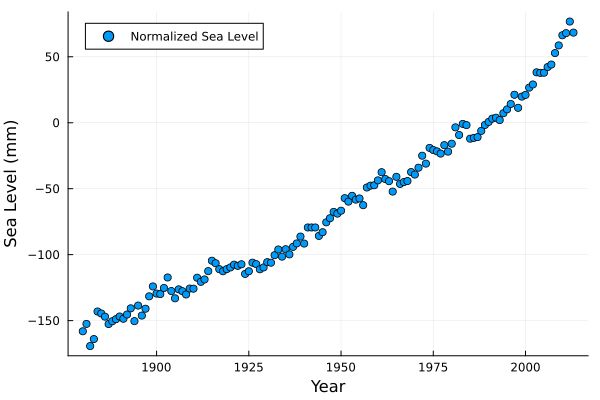

In [267]:
temp_df = CSV.read("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", DataFrame)
sea_level_df = CSV.read("data/CSIRO_Recons_gmsl_yr_2015.csv", DataFrame)

# Adjust time in sea level dataset to match temp_df
sea_level_df[!, "Adjusted_Time"] = sea_level_df."Time" .- 0.5

# Find mean
temp_range = []
for i in 1:nrow(temp_df)
    if 1980 ≤ temp_df[i, "Time"] ≤ 1999
        push!(temp_range, temp_df[i, "Anomaly (deg C)"])
    end
end

sea_level_range = []
for i in 1:nrow(sea_level_df)
    if 1980 ≤ sea_level_df[i, "Time"] ≤ 1999
        push!(sea_level_range, sea_level_df[i, "GMSL (mm)"])
    end
end

# Compute means
temp_mean = mean(temp_range)
sea_level_mean = mean(sea_level_range)
println(sea_level_mean)

# Normalize data
temp_df."Normalized Anomaly (deg C)" = temp_df."Anomaly (deg C)" .- temp_mean
sea_level_df."Normalized GMSL (mm)" = sea_level_df."GMSL (mm)" .- sea_level_mean

scatter(temp_df."Time", temp_df."Normalized Anomaly (deg C)", label="Normalized Temperature", xlabel="Year", ylabel="Temperature Anomaly (°C)")
scatter(sea_level_df."Adjusted_Time", sea_level_df."Normalized GMSL (mm)", label="Normalized Sea Level", xlabel="Year", ylabel="Sea Level (mm)")
#println(sea_level_df)

In [ ]:
# Define the common year range
common_years = 1880:2013

# Filter both datasets to keep only the common years
temp_subset = filter(row -> row."Time" in common_years, temp_df)
sea_level_subset = filter(row -> row."Adjusted_Time" in common_years, sea_level_df)

# Function to simulate sea level rise
function simulate_sea_level(temp_subset, a, b, tau, S0)
    years = temp_subset."Time"
    S = zeros(length(years))
    S[1] = S0
    T = temp_subset."Normalized Anomaly (deg C)"
    
    # Simulate sea level rise year by year using Euler's method
    for i in 2:length(years)
        S_eq = a * T[i] + b
            S[i] = S[i-1] + (S_eq - S[i-1]) *(1/tau)
    end
    return S
end

simulate_sea_level (generic function with 2 methods)

In [272]:
# Log-likelihood function
function likelihood(params, temp_data, sea_level_data)
    a, b, tau, S0 = params
    S_sim = simulate_sea_level(temp_data, a, b, tau, S0)
    residuals = sea_level_data."Normalized GMSL (mm)" - S_sim
    
    sigma = std(residuals)
    return -sum(logpdf.(Normal.(0, sigma), residuals))
end

initial_guess = [1300.0, 770.0, 200.0, -157.0] # a, b, tau, S0 from (Grinsted et al, 2010)
lb = [100.0, 50.0, 50.0, -170.0]
ub = [2500.0, 1500.0, 4000.0, -155]

optim_out = Optim.optimize(params -> likelihood(params, temp_subset, sea_level_subset), 
                           lb, ub, initial_guess)

# Extract best-fit parameters
a_fit, b_fit, tau_fit, S0_fit = round.(optim_out.minimizer; digits=2)
println("Best-fit parameters: a=$a_fit, b=$b_fit, tau=$tau_fit, S0=$S0_fit)")

Best-fit parameters: a=566.92, b=432.89, tau=189.11, S0=-156.71)


Residuals mean: 0.004885712724272852, std: 5.83508771495183


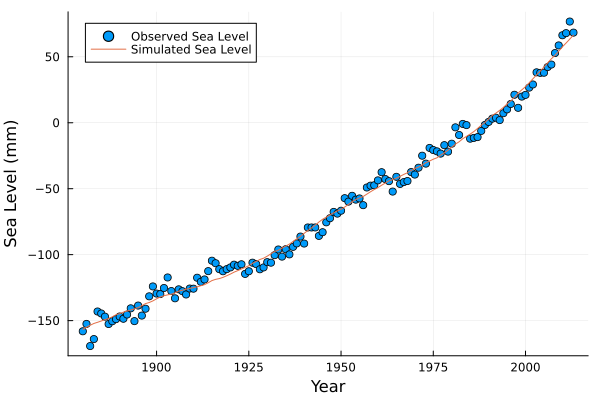

In [273]:
S_sim = simulate_sea_level(temp_subset, a_fit, b_fit, tau_fit, S0_fit)
residuals = sea_level_subset."Normalized GMSL (mm)" .- S_sim

# Report results
println("Residuals mean: $(mean(residuals)), std: $(std(residuals))")

# Plot results
scatter(temp_subset.Time, sea_level_subset."Normalized GMSL (mm)", label="Observed Sea Level", xlabel="Year", ylabel="Sea Level (mm)", legend=:topleft)
plot!(temp_subset.Time, S_sim, label="Simulated Sea Level")

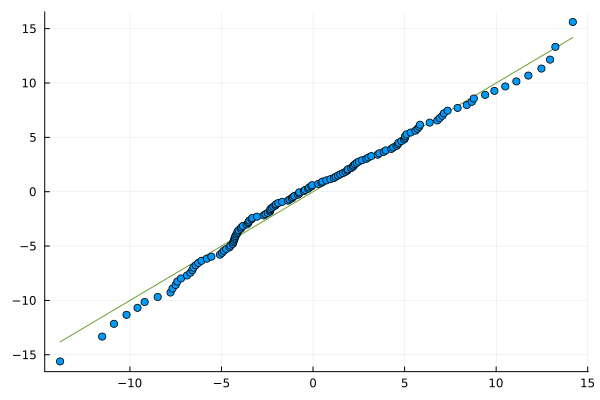

In [274]:
histogram(residuals, bins=30, label="Residuals Distribution")
qqplot(residuals, Normal(0, std(residuals)))

The best-fit parameters: a=566.92, b=432.89, tau=189.11, S0=-156.71.

The plot demonstrates a strong positive correlation between global mean temperature increases and global mean sea level rise. The simulated sea level plot shows that the simulated sea level rise closely follows the observed data, with minimal residuals (0.00489), indicating that temperature anomalies are a strong predictor of sea level changes. Additionally, the residual analysis suggests that the model performs well, with only minor deviations.

### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

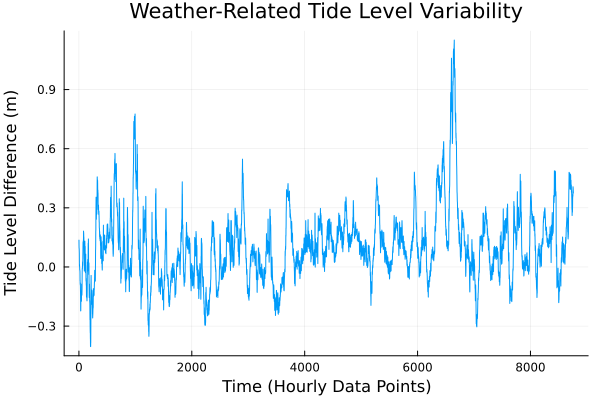

In [ ]:
df = CSV.read("data/norfolk-hourly-surge-2015.csv", DataFrame)

# Compute variability
df.weather_variability = df."Verified (m)" .- df."Predicted (m)"

# Plot
plot(df.weather_variability, title="Weather-Related Tide Level Variability",
     xlabel="Time (Hourly Data Points)", ylabel="Tide Level Difference (m)", legend=false)

Based on the plot, the series doesn’t show a clear upward or downward trend, therefore I assumed it is satationary.

┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/liyingma/.julia/packages/Plots/Ec1L1/src/args.jl:1149


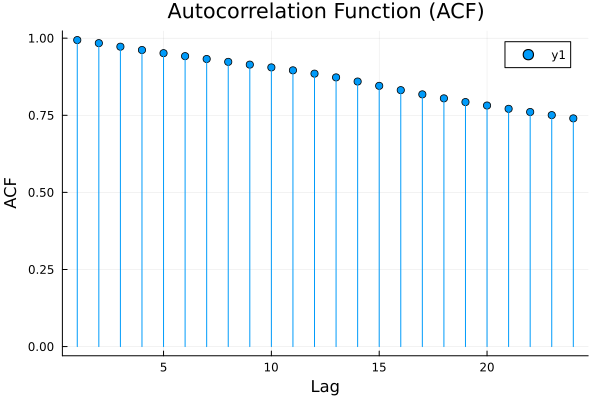

In [ ]:
# Next step, check if it is appropriate to use AR model.
lags = 24 # Since the data is hourly, this represents one-day cycles
acf_vals = autocor(df.weather_variability, 1:lags)
plot(1:lags, acf_vals, seriestype=:stem, marker=:cirle, title="Autocorrelation Function (ACF)", xlabel="Lag", ylabel="ACF")

The ACF gradually decreased, suggesting that an AR model could be a good choice.

┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/liyingma/.julia/packages/Plots/Ec1L1/src/args.jl:1149


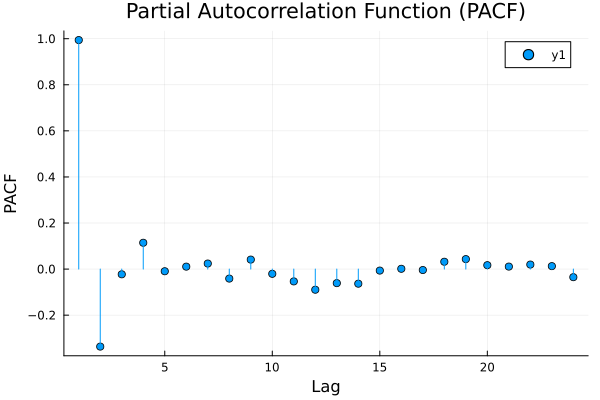

In [104]:
# Next step, check the appropriate AR model order p.

pacf_vals = pacf(df.weather_variability, 1:lags)
plot(1:lags, pacf_vals, seriestype=:stem, marker=:cirle, title="Partial Autocorrelation Function (PACF)", xlabel="Lag", ylabel="PACF")

Based on the plot, it it clear that the PACF has a significant spike at lag 1 and then drops. Therefore AR(1) would be a good choice.

In [89]:
# Next, using MLE check the estimated coefficient ρ.

function ar1_loglik_whitened(θ, dat) # Source: BEE4580 Lecture 5 Time Series Example Code
    # might need to include mean or trend parameters as well
    # subtract trend from data to make this mean-zero in this case
    ρ, σ = θ
    T = length(dat)
    ll = 0 # initialize log-likelihood counter
    for i = 1:T
        if i == 1
            ll += logpdf(Normal(0, sqrt(σ^2 / (1 - ρ^2))), dat[i])
        else
            ll += logpdf(Normal(ρ * dat[i-1], σ), dat[i])
        end
    end
    return -ll # Negative log-likelihood for minimization
end

y = df.weather_variability
initial_guess = [0.5, std(y)]

# Constrain ρ to be between -1 and 1, and σ to be strictly positive
lb = [-1.0, 1e-6] 
ub = [1.0, 10.0] 

result = optimize(θ -> ar1_loglik_whitened(θ, y), lb, ub, initial_guess)

# Extract estimated parameters
ρ_hat, σ_hat = Optim.minimizer(result)

println("Estimated AR(1) Coefficient ()ρ: ", round(ρ_hat, digits=3))
println("Estimated Noise Std Dev (σ): ", round(σ_hat, digits=3))


Estimated AR(1) Coefficient (ρ): 0.996
Estimated Noise Std Dev (σ): 0.02


Since ρ is very close to 1, this indicates the series is likely non-stationary, contradicting the earlier visual assumption. (Source)

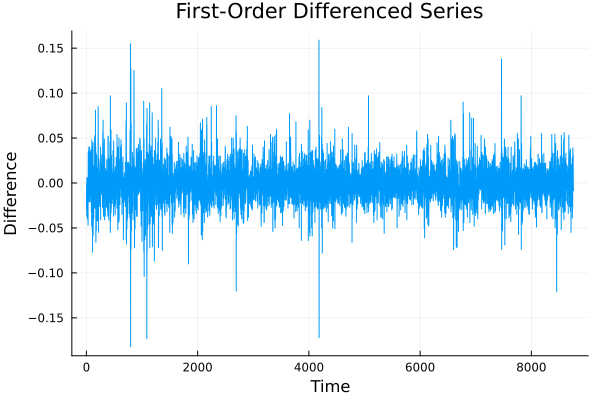

In [105]:
# To address non-stationarity, applied first-order differencing

diff_series = diff(df.weather_variability)

# Plot
plot(diff_series, title="First-Order Differenced Series", xlabel="Time", ylabel="Difference", legend=false)

The differenced series was visually more stable.

┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/liyingma/.julia/packages/Plots/Ec1L1/src/args.jl:1149


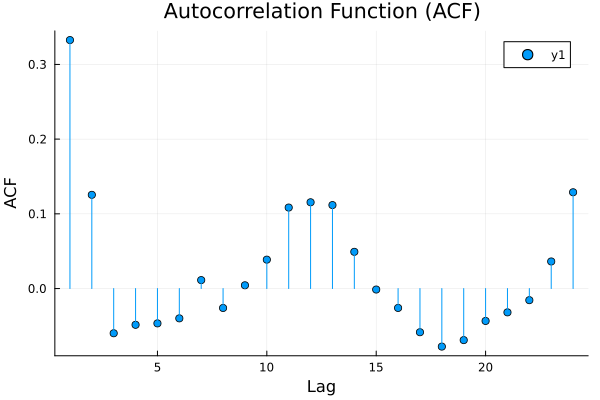

In [106]:
# Gerate ACF and PACF to see if it is approperate to apply AR model, and the order of the model.

lags = 24
acf_vals = autocor(diff_series, 1:lags)
plot(1:lags, acf_vals, seriestype=:stem, marker=:cirle, title="Autocorrelation Function (ACF)", xlabel="Lag", ylabel="ACF")

┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/liyingma/.julia/packages/Plots/Ec1L1/src/args.jl:1149


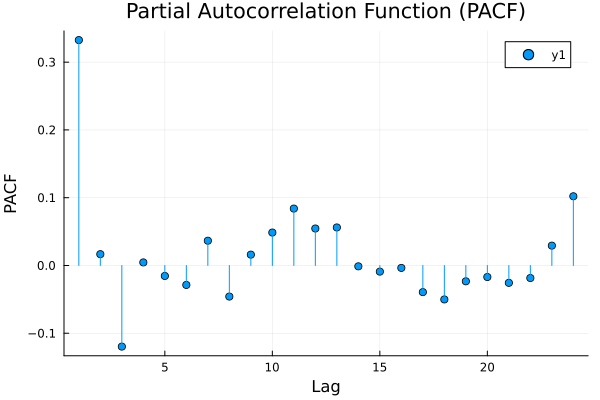

In [107]:
pacf_vals = pacf(diff_series, 1:lags)
plot(1:lags, pacf_vals, seriestype=:stem, marker=:cirle, title="Partial Autocorrelation Function (PACF)", xlabel="Lag", ylabel="PACF")

The ACF decayed much fasterand the PACF again showed a significant spike at lag 1, confirming that AR(1) is still the best choice.

In [98]:
y = diff_series
# Initial guess
initial_guess = [0.5, std(y)]

# Constrain ρ to be between -1 and 1, and σ to be strictly positive
lb = [-1.0, 1e-6] 
ub = [1.0, 10.0] 

result = optimize(θ -> ar1_loglik_whitened(θ, y), lb, ub, initial_guess)

# Extract estimated parameters
ρ_hat, σ_hat = Optim.minimizer(result)

println("Estimated AR(1) Coefficient (ρ): ", round(ρ_hat, digits=3))
println("Estimated Noise Std Dev (σ): ", round(σ_hat, digits=3))

Estimated AR(1) Coefficient (ρ): 0.333
Estimated Noise Std Dev (σ): 0.019


This time the values of ρ is more reasonable, indicating stationarity was successfully achieved.

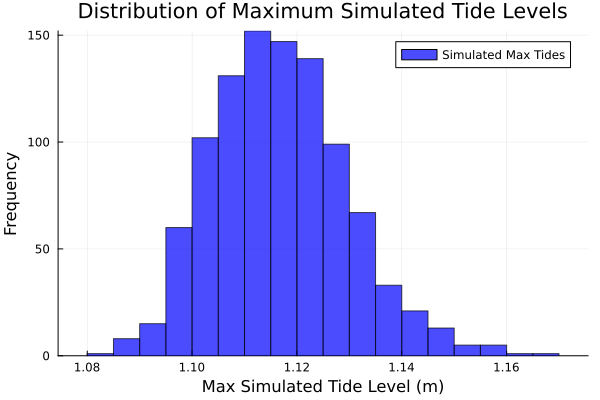

In [101]:
# Function to simulate an AR(1) process
function simulate_ar1(ρ, σ, length)
    sim_series = zeros(length)
    sim_series[1] = rand(Normal(0, sqrt(σ^2 / (1 - ρ^2))))  # Initial value

    for t in 2:length
        sim_series[t] = ρ * sim_series[t-1] + rand(Normal(0, σ))
    end
    return sim_series
end

# Simulate 1,000 AR(1) realizations
n_simulations = 1000
simulated_max_tides = Float64[]

for _ in 1:n_simulations
    sim_weather_variability = simulate_ar1(0.333, 0.019, length(df."Predicted (m)"))
    sim_tide_levels = df."Predicted (m)" .+ sim_weather_variability
    push!(simulated_max_tides, maximum(sim_tide_levels))
end

# Plot distribution of simulated maximum tide levels
histogram(simulated_max_tides, bins=30, alpha=0.7, color=:blue, xlabel="Max Simulated Tide Level (m)", ylabel="Frequency",
          title="Distribution of Maximum Simulated Tide Levels", label="Simulated Max Tides")


In [102]:
# Compare with observed maximum tide level
observed_max_tide = maximum(df."Verified (m)")
println("Observed Maximum Tide Level: ", round(observed_max_tide, digits=3), " m")
println("Mean of Simulated Maximum Tides: ", round(mean(simulated_max_tides), digits=3), " m")

Observed Maximum Tide Level: 1.977 m
Mean of Simulated Maximum Tides: 1.117 m


The simulated maximum tide levels were significantly lower than the observed maximum, suggesting that the AR(1) model may not fully capture extreme weather-driven events.

## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

In [118]:
df = CSV.read("data/salamanders.csv", DataFrame)

# Standardize Pctcover and Forestage
pct_mean = mean(df."PCTCOVER")
pct_std = std(df."PCTCOVER")
fore_mean = mean(df."FORESTAGE")
fore_std = std(df."FORESTAGE")

df."PCTCOVER" = (df."PCTCOVER" .- pct_mean) ./ pct_std
df."FORESTAGE" = (df."FORESTAGE" .- fore_mean) ./ fore_std

#@show(df)

47-element Vector{Float64}:
  0.760627471116639
 -0.417586460725787
  1.9595118228159494
 -0.541608979867095
 -0.6501286841157394
  1.0293429292561396
  0.1611852952669837
 -0.5054357451175469
 -0.6552962890799606
  1.975014637708613
  ⋮
 -0.5777822146166431
 -0.5674470046882008
 -0.46926251036799865
 -0.6139554493661913
  0.7812978909735236
  1.2515499427176497
 -0.18504423733583447
 -0.5622793997239797
  0.09400643073210851

In [271]:
# Define the Poisson log-likelihood function (Source: BEE4850 Lecture 04 Slides)
function salamander_model(params, pctcover, salamander_counts)
    β₀, β₁ = params
    λ = exp.(β₀ .+ β₁ * pctcover)
    loglik = sum(logpdf.(Poisson.(λ), salamander_counts))
    return -loglik  # Negative log-likelihood for minimization
end

# Define bounds and initial values for the parameters
lb = [-10.0, -10.0] 
ub = [10.0, 10.0]    
init = [0.0, 0.0]      

optim_out = optimize(θ -> salamander_model(θ, df."PCTCOVER", df."SALAMAN"), lb, ub, init)
θ_mle = optim_out.minimizer

@show round.(θ_mle; digits=3)

round.(θ_mle; digits = 3) = [0.43, 1.16]


2-element Vector{Float64}:
 0.43
 1.16

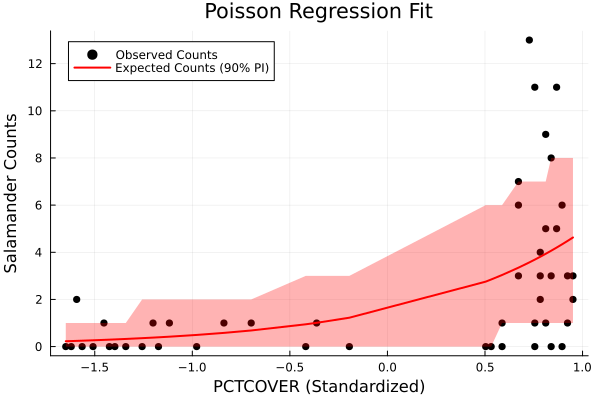

In [ ]:
# Extract the estimated parameters
β₀, β₁ = θ_mle

# Calculate expected counts (λ)
expected_counts = exp.(β₀ .+ β₁ * df."PCTCOVER")

# Calculate 90% prediction intervals
lower_bound = quantile.(Poisson.(expected_counts), 0.05)
upper_bound = quantile.(Poisson.(expected_counts), 0.95)

# Ensure data is sorted for proper plotting (Consulted GPT, please see references)
sorted_indices = sortperm(df."PCTCOVER")  # Get sorting indices
sorted_pctcover = df."PCTCOVER"[sorted_indices]  # Sort PCTCOVER
sorted_expected = expected_counts[sorted_indices]  # Sort expected counts
sorted_lower = lower_bound[sorted_indices]  # Sort lower bound
sorted_upper = upper_bound[sorted_indices]  # Sort upper bound

# Create the scatter plot for observed counts
scatter(df."PCTCOVER", df."SALAMAN", label="Observed Counts", xlabel="PCTCOVER (Standardized)", ylabel="Salamander Counts", title="Poisson Regression Fit", color=:black)

# Add the fitted line and shaded confidence interval
plot!(sorted_pctcover, sorted_expected, ribbon=(sorted_expected .- sorted_lower, sorted_upper .- sorted_expected), color=:red, fillalpha=0.3, label="Expected Counts (90% PI)", linewidth=2)

As the percentage of ground cover increases, the expected salamander counts increase as well, suggesting a positive relationship between salamander abundance and ground cover. At lower values of percentage of ground cover, the model predicts counts close to zero, which aligns well with the observations. However, the Poisson model assumes the variance equals the mean, but from the plot, it appears that variance increases more rapidly than the mean, suggesting overdispersion.

In [121]:
# Define the Poisson log-likelihood function
function salamander_model_improved(params, pctcover, forestage, salamander_counts)
    β₀, β₁, β₂ = params
    λ = exp.(β₀ .+ β₁ * pctcover .+ β₂ * forestage)
    loglik = sum(logpdf.(Poisson.(λ), salamander_counts))
    return -loglik  # Negative log-likelihood for minimization
end

# Define bounds and initial values for the parameters
lb = [-10.0, -10.0, -10.0] 
ub = [10.0, 10.0, 10.0]   
init = [0.0, 0.0, 0.0]      

# Optimize the model
optim_out = optimize(θ -> salamander_model_improved(θ, df."PCTCOVER", df."FORESTAGE", df."SALAMAN"), lb, ub, init)
θ_mle = optim_out.minimizer

@show round.(θ_mle; digits=3)

round.(θ_mle; digits = 3) = [0.429, 1.162, -0.004]


3-element Vector{Float64}:
  0.429
  1.162
 -0.004

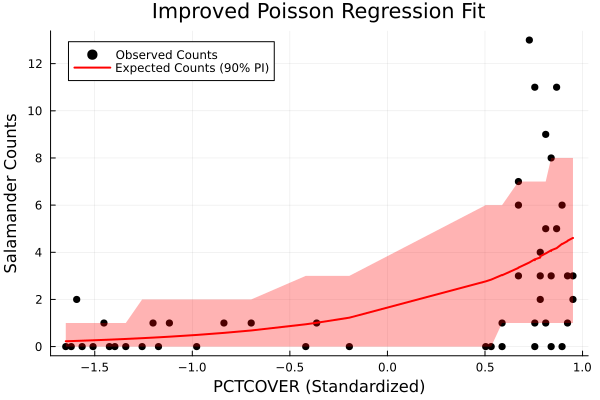

In [122]:
# Extract the estimated parameters
β₀, β₁, β₂ = θ_mle

# Calculate expected counts (λ)
expected_counts = exp.(β₀ .+ β₁ * df."PCTCOVER" .+ β₂ * df."FORESTAGE")

# Calculate 90% prediction intervals
lower_bound = quantile.(Poisson.(expected_counts), 0.05)
upper_bound = quantile.(Poisson.(expected_counts), 0.95)

sorted_indices_im = sortperm(df."PCTCOVER")  # Get sorting indices
sorted_pctcover_im = df."PCTCOVER"[sorted_indices]  # Sort PCTCOVER
sorted_expected_im = expected_counts[sorted_indices]  # Sort expected counts
sorted_lower_im = lower_bound[sorted_indices]  # Sort lower bound
sorted_upper_im = upper_bound[sorted_indices]  # Sort upper bound

# Create the scatter plot for observed counts
scatter(df."PCTCOVER", df."SALAMAN", label="Observed Counts", xlabel="PCTCOVER (Standardized)", ylabel="Salamander Counts", title="Improved Poisson Regression Fit", color=:black)

# Add the fitted line and shaded confidence interval
plot!(sorted_pctcover_im, sorted_expected_im, ribbon=(sorted_expected_im .- sorted_lower_im, sorted_upper_im .- sorted_expected_im), color=:red, fillalpha=0.3, label="Expected Counts (90% PI)", linewidth=2)

The estimated coefficients (0.429, 1.162, -0.004) suggest that forest age has a negligible effect, as its coefficient is very close to zero (-0.004). If forest age were an important factor, we would expect its coefficient to be larger in magnitude. The updated model’s prediction intervals (red shaded region) and expected values (red line) remain similar to the previous model, indicating no major changes in fit. This might due to ground cover already captures most of the habitat suitability, forest age might not provide additional predictive power.

### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

## References